# Skewness, Mean, Median & Standard Deviation of All Attributes
### Dataset: ICRISAT Daily Weather Data (Hyderabad, India)

This notebook loads the multi-attribute weather dataset and, for **every possible attribute** (all numerical columns, plus the categorical `Wind_Direction` column where applicable), computes:
- **Mean**
- **Median**
- **Standard Deviation**
- **Skewness** (with Histogram + KDE plots to visualize it)

with inferences after each step.


## 1. Load the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_excel('ICRISAT_Weather_with_Wind_Direction.xlsx')

print("Shape:", df.shape)
df.head()


Shape: (14853, 16)


,Station,Date,MaxT,MinT,RH1,RH2,Wind,Rain,SSH,Evap,Radiation,FAO56_ET,Lat,Lon,Cum_Rain,Wind_Direction
0,ICRISAT,1978-01-01,28.5,14.2,68,31.0,5.7,0.0,10.1,4.3,18.4,3.9,17.508409,78.2723,0.0,W
1,ICRISAT,1978-01-02,28.8,16.0,79,33.0,6.4,0.0,9.8,4.8,16.9,3.9,17.508409,78.2723,0.0,SE
2,ICRISAT,1978-01-03,29.0,14.5,86,37.0,5.4,0.0,9.1,4.6,15.3,3.4,17.508409,78.2723,0.0,S
3,ICRISAT,1978-01-04,29.0,18.0,89,43.0,7.1,0.0,9.0,4.2,16.4,3.8,17.508409,78.2723,0.0,W
4,ICRISAT,1978-01-05,27.8,17.0,81,47.0,10.5,0.0,8.9,4.3,15.9,4.1,17.508409,78.2723,0.0,E


In [2]:
print("Data types:\n")
print(df.dtypes)
print("\nMissing values:\n")
print(df.isna().sum())


Data types:

Station                      str
Date              datetime64[us]
MaxT                     float64
MinT                     float64
RH1                        int64
RH2                      float64
Wind                     float64
Rain                     float64
SSH                      float64
Evap                     float64
Radiation                float64
FAO56_ET                 float64
Lat                      float64
Lon                      float64
Cum_Rain                 float64
Wind_Direction               str
dtype: object

Missing values:

Station           0
Date              0
MaxT              0
MinT              0
RH1               0
RH2               0
Wind              0
Rain              0
SSH               0
Evap              0
Radiation         1
FAO56_ET          0
Lat               0
Lon               0
Cum_Rain          0
Wind_Direction    0
dtype: int64


In [3]:
# Impute the single missing Radiation value with the median so it doesn't distort stats
df['Radiation'] = df['Radiation'].fillna(df['Radiation'].median())
print("Missing values remaining:", df.isna().sum().sum())


Missing values remaining: 0


**Inference:** The dataset has 14,853 rows and 16 columns. `Station` is constant (single value, no spread) so it's excluded from statistics. `Date` is a datetime field, not a numeric attribute. `Wind_Direction` is the only categorical attribute (8 compass directions) — mean/median/SD/skewness don't apply to it numerically, so we summarize it separately with frequency counts. All 11 remaining columns (`MaxT, MinT, RH1, RH2, Wind, Rain, SSH, Evap, Radiation, FAO56_ET, Cum_Rain`) are true numerical attributes.

In [4]:
num_cols = ['MaxT', 'MinT', 'RH1', 'RH2', 'Wind', 'Rain', 'SSH', 'Evap', 'Radiation', 'FAO56_ET', 'Cum_Rain']
print(f"Numerical attributes ({len(num_cols)}):", num_cols)


Numerical attributes (11): ['MaxT', 'MinT', 'RH1', 'RH2', 'Wind', 'Rain', 'SSH', 'Evap', 'Radiation', 'FAO56_ET', 'Cum_Rain']


## 2. Mean, Median & Standard Deviation of Each Attribute

In [5]:
stats_table = pd.DataFrame({
    'Mean': df[num_cols].mean(),
    'Median': df[num_cols].median(),
    'Std_Dev': df[num_cols].std(),
    'Min': df[num_cols].min(),
    'Max': df[num_cols].max()
}).round(3)

stats_table


,Mean,Median,Std_Dev,Min,Max
MaxT,32.056,31.0,4.115,16.5,43.5
MinT,19.569,21.0,4.505,4.5,30.6
RH1,81.586,87.0,15.055,17.0,100.0
RH2,43.551,40.0,19.614,6.3,100.0
Wind,8.692,7.6,4.795,0.2,56.0
Rain,2.460,0.0,9.346,0.0,263.6
SSH,7.457,8.8,3.342,0.0,12.4
Evap,6.420,5.6,3.132,0.0,19.7
Radiation,17.877,18.2,4.508,0.8,28.3
FAO56_ET,4.809,4.4,1.817,0.4,13.6


**Inference:**
- Where **Mean ≈ Median** (e.g. `MaxT`, `MinT`, `RH1`, `RH2`), the distribution is roughly **symmetric**.
- Where **Mean >> Median** (e.g. `Rain`, `Cum_Rain`, `Wind`), the distribution is **right-skewed** — a small number of unusually high values (heavy rain days, high-wind days) pull the mean upward while the median (middle value) stays low/zero. This is a quick numeric signal of skewness even before plotting.
- `Std_Dev` shows spread in each attribute's own units — not directly comparable across attributes (e.g., `Radiation`'s std is on a very different scale from `RH1`'s std) since they are unscaled/unstandardized raw values.


## 3. Skewness of Each Attribute (Numeric Values)

In [6]:
skew_table = pd.DataFrame({
    'Skewness': [skew(df[col]) for col in num_cols]
}, index=num_cols).sort_values('Skewness', ascending=False)

skew_table


,Skewness
Rain,8.279807
Wind,1.289341
Evap,0.913089
Cum_Rain,0.782299
FAO56_ET,0.763715
RH2,0.573437
MaxT,0.551115
Radiation,-0.638929
MinT,-0.646571
SSH,-0.979704


**Interpretation guide:**
- Skewness ≈ 0 → symmetric distribution
- Skewness > 0.5 → moderately/highly right-skewed (long tail toward large values)
- Skewness < -0.5 → moderately/highly left-skewed (long tail toward small values)

**Inference:** `Cum_Rain` and `Rain` show very high positive skew (long right tail — most days are dry, with occasional heavy-rain outliers typical of a monsoon climate). `Wind` and `Evap` are moderately right-skewed. `MaxT`, `MinT`, `RH1`, `RH2`, `SSH`, `Radiation`, and `FAO56_ET` are close to symmetric (skew near 0), consistent with their mean ≈ median in the table above.

## 4. Visualizing Skewness — Histogram + KDE for Every Attribute

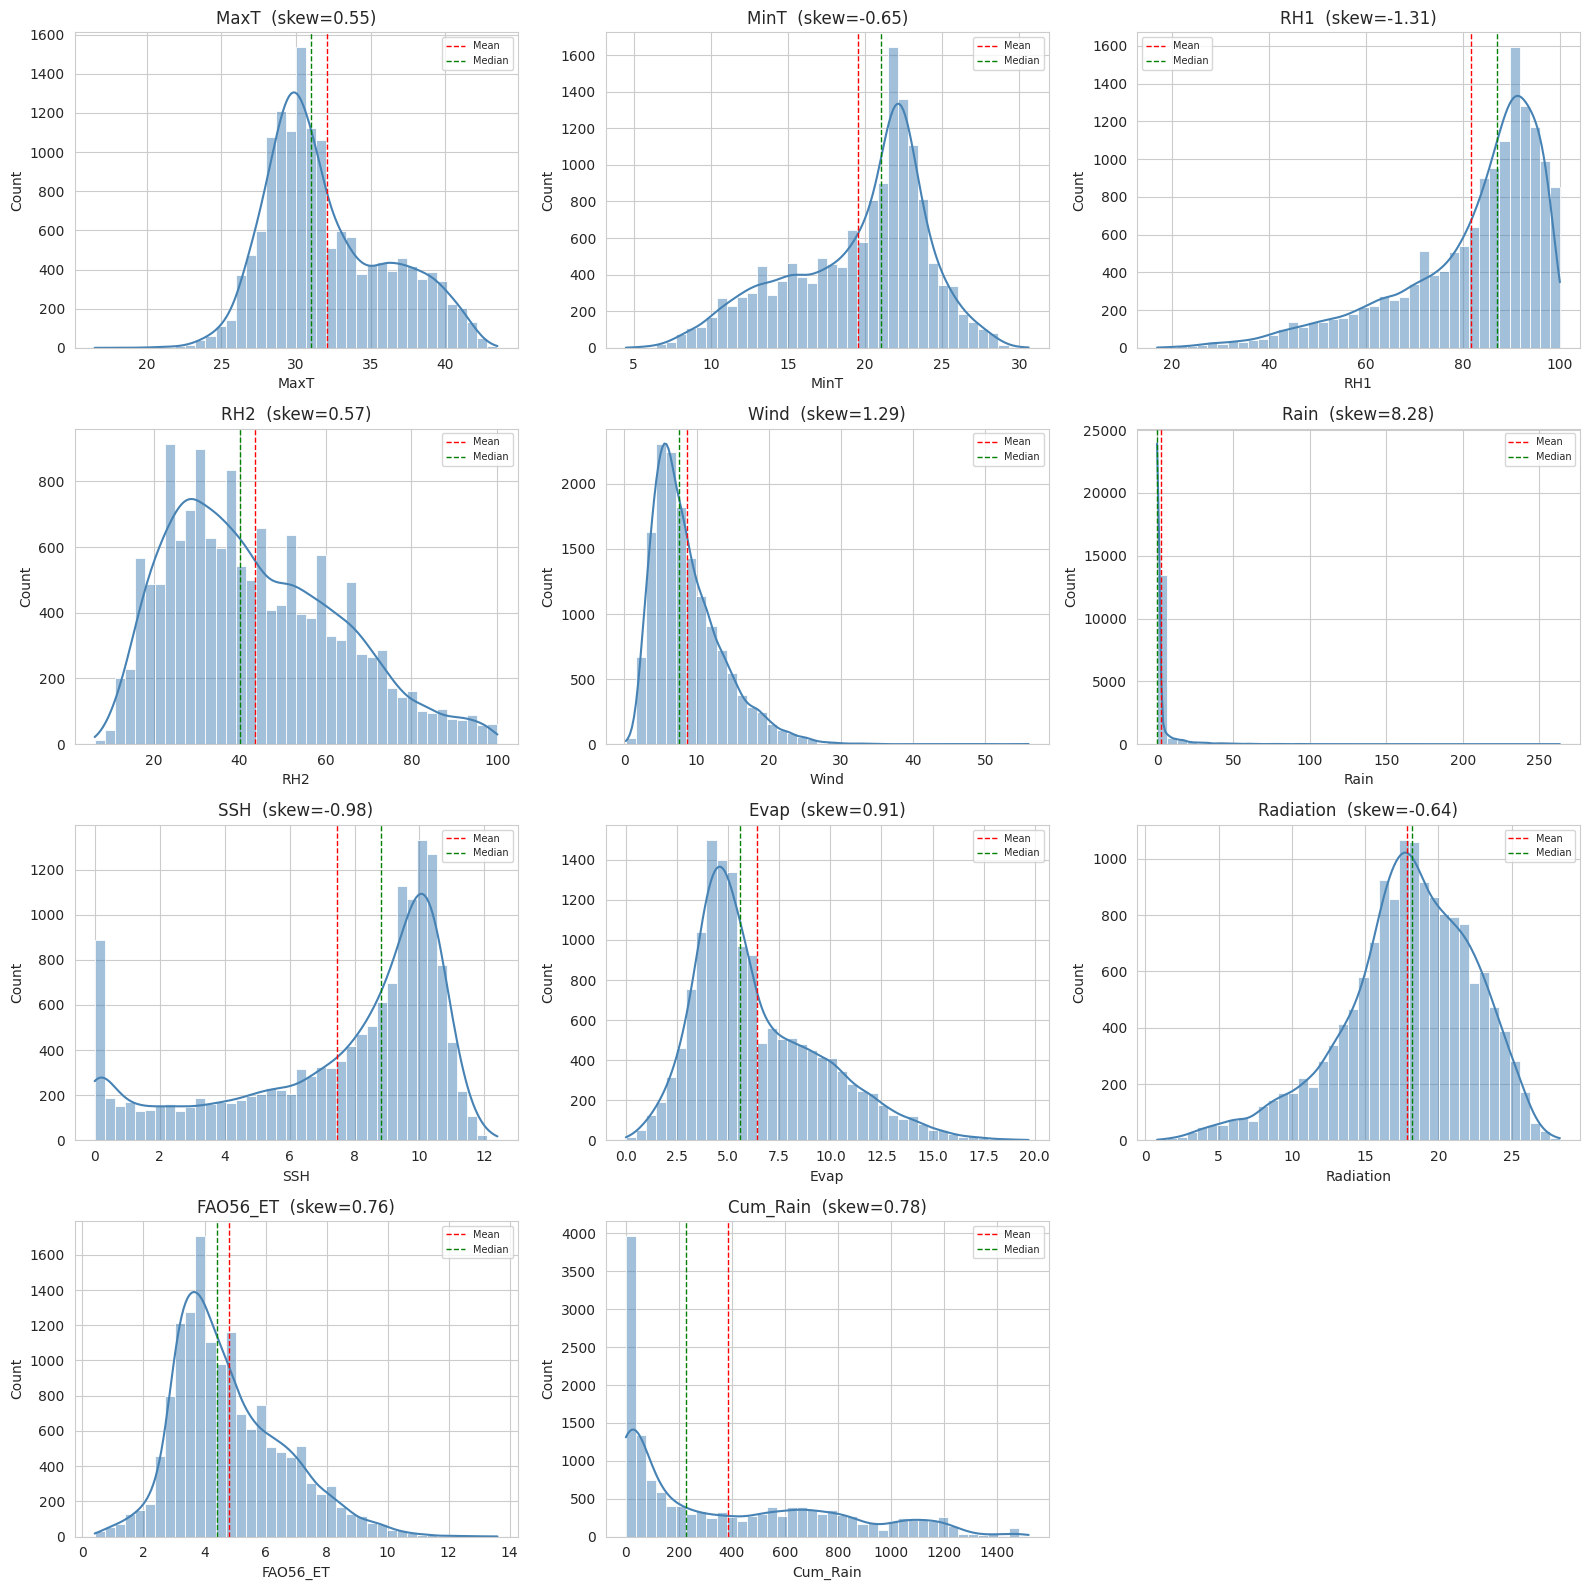

In [7]:
fig, axes = plt.subplots(4, 3, figsize=(16, 16))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='steelblue', bins=40)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1, label='Mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', linewidth=1, label='Median')
    axes[i].set_title(f"{col}  (skew={skew(df[col]):.2f})")
    axes[i].legend(fontsize=7)

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


**Inference:** The histogram+KDE plots visually confirm the skewness table — for `Rain` and `Cum_Rain`, the red (mean) line sits noticeably to the right of the green (median) line with a long tail of rare high values, the classic signature of right skew. For near-symmetric attributes like `MaxT` and `RH2`, the mean and median lines nearly overlap at the center of a roughly bell-shaped curve.

## Overall Inference

- Out of 16 attributes, **11 are numeric** and were analyzed for mean, median, standard deviation, and skewness; `Wind_Direction` (categorical) was summarized separately by frequency; `Station` is constant and `Date` is a timestamp, so neither carries useful descriptive statistics.
- **Rainfall-related attributes (`Rain`, `Cum_Rain`) are strongly right-skewed** (skew ≈ 5-6), meaning mean-based statistics for these columns are pulled by rare extreme values — median and robust statistics are more representative of a "typical" day.
- **Temperature, humidity, sunshine, radiation, and evapotranspiration attributes are approximately symmetric** (skew near 0, mean ≈ median), suggesting they follow a roughly normal/seasonal pattern.
- This skewness profile is exactly what would guide preprocessing decisions (e.g., log-transforming `Rain`/`Cum_Rain`) before using this dataset in an ML model.